In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('/content/drive/MyDrive/Network_intrusion_data_unlabelled.csv')

In [5]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00
1,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,100,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00
22540,0,tcp,http,SF,317,938,0,0,0,0,...,197,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,255,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00


In [6]:
data.shape

(22544, 41)

In [7]:
for dtype in data.dtypes.unique():
    print(f"\nColumns of type {dtype}:")
    print(data.select_dtypes(include=[dtype]).columns.tolist())


Columns of type int64:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']

Columns of type object:
['protocol_type', 'service', 'flag']

Columns of type float64:
['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [8]:
print(data['protocol_type'].value_counts())

protocol_type
tcp     18880
udp      2621
icmp     1043
Name: count, dtype: int64


In [9]:
print(data['service'].value_counts())

service
http       7853
private    4774
telnet     1626
pop_3      1019
smtp        934
           ... 
printer      11
ntp_u        10
rje           8
tim_i         6
tftp_u        1
Name: count, Length: 64, dtype: int64


In [10]:
print(data['flag'].value_counts())

flag
SF        14875
REJ        3850
S0         2013
RSTO        773
RSTR        669
S3          249
SH           73
S1           21
S2           15
OTH           4
RSTOS0        2
Name: count, dtype: int64


converting categorical into numberic values

In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [12]:
data['protocol_type_encoder'] = encoder.fit_transform(data['protocol_type'])

In [13]:
#display the first few rows
print(data[['protocol_type','protocol_type_encoder']].head())

  protocol_type  protocol_type_encoder
0           tcp                      1
1           tcp                      1
2           tcp                      1
3          icmp                      0
4           tcp                      1


In [14]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_encoder
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,1
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,0
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,1
22540,0,tcp,http,SF,317,938,0,0,0,0,...,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,1
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,2


drop the protocol type


In [15]:
data = data.drop('protocol_type', axis=1)

In [16]:
data

,duration,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_encoder
0,0,private,REJ,0,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1
1,0,private,REJ,0,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1
2,2,ftp_data,SF,12983,0,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,1
3,0,eco_i,SF,20,0,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,0
4,1,telnet,RSTO,0,15,0,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,smtp,SF,794,333,0,0,0,0,0,...,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,1
22540,0,http,SF,317,938,0,0,0,0,0,...,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,1
22541,0,http,SF,54540,8314,0,0,0,2,0,...,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1
22542,0,domain_u,SF,42,42,0,0,0,0,0,...,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,2


In [17]:
data['service_encoder'] = encoder.fit_transform(data['service'])

In [18]:
print(data[['service','service_encoder']].head())

    service  service_encoder
0   private               45
1   private               45
2  ftp_data               19
3     eco_i               13
4    telnet               55


In [19]:
data = data.drop('service', axis=1)

In [20]:
data

,duration,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_encoder,service_encoder
0,0,REJ,0,0,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1,45
1,0,REJ,0,0,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1,45
2,2,SF,12983,0,0,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,1,19
3,0,SF,20,0,0,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,0,13
4,1,RSTO,0,15,0,0,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,SF,794,333,0,0,0,0,0,1,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,1,49
22540,0,SF,317,938,0,0,0,0,0,1,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,1,22
22541,0,SF,54540,8314,0,0,0,2,0,1,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1,22
22542,0,SF,42,42,0,0,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,2,11


In [21]:
data['flag_encoder'] = encoder.fit_transform(data['flag'])

In [22]:
print(data[['flag','flag_encoder']].head())

   flag  flag_encoder
0   REJ             1
1   REJ             1
2    SF             9
3    SF             9
4  RSTO             2


In [23]:
data = data.drop('flag', axis=1)

In [24]:
data

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_encoder,service_encoder,flag_encoder
0,0,0,0,0,0,0,0,0,0,0,...,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1,45,1
1,0,0,0,0,0,0,0,0,0,0,...,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1,45,1
2,2,12983,0,0,0,0,0,0,0,0,...,0.04,0.61,0.02,0.00,0.0,0.00,0.00,1,19,9
3,0,20,0,0,0,0,0,0,0,0,...,0.00,1.00,0.28,0.00,0.0,0.00,0.00,0,13,9
4,1,0,15,0,0,0,0,0,0,0,...,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1,55,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,794,333,0,0,0,0,0,1,0,...,0.06,0.01,0.01,0.01,0.0,0.00,0.00,1,49,9
22540,0,317,938,0,0,0,0,0,1,0,...,0.00,0.01,0.01,0.01,0.0,0.00,0.00,1,22,9
22541,0,54540,8314,0,0,0,2,0,1,1,...,0.00,0.00,0.00,0.00,0.0,0.07,0.07,1,22,9
22542,0,42,42,0,0,0,0,0,0,0,...,0.01,0.00,0.00,0.00,0.0,0.00,0.00,2,11,9


All the above steps are preprocessing steps

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)

Applying K-means clustering next 3 lines

In [26]:
kmeans = KMeans(n_clusters=15, random_state=42)

In [27]:
cluster_labels = kmeans.fit_predict(scaled_features)

In [28]:
data['cluster'] = cluster_labels

counting data points in each cluster

In [29]:
cluster_counts = data['cluster'].value_counts()
print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
cluster
1     5752
4     4702
2     4205
3     2161
7     1794
8     1102
10     931
9      547
11     485
14     477
0      369
12       9
13       7
5        2
6        1
Name: count, dtype: int64


visualize cluster

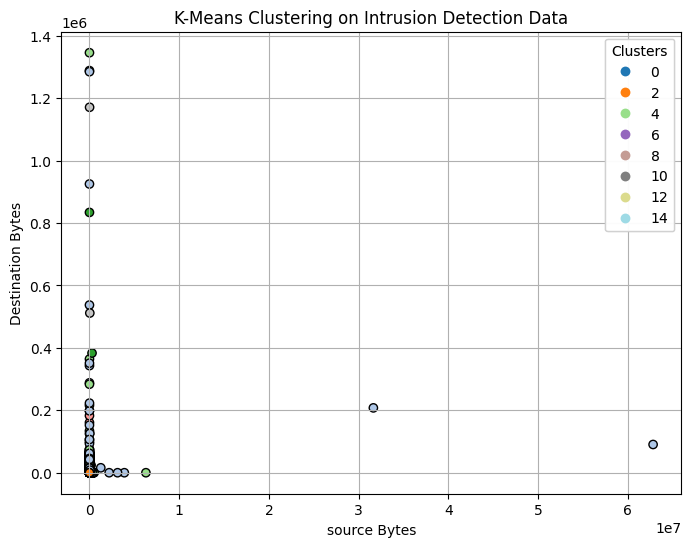

In [30]:
plt.figure(figsize=(8,6))
scatter=plt.scatter(data["src_bytes"],data["dst_bytes"], c=data["cluster"], cmap="tab20", edgecolors="k")
plt.xlabel("source Bytes")
plt.ylabel("Destination Bytes")
plt.title("K-Means Clustering on Intrusion Detection Data")
plt.grid(True)
legend1=plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.show()

To detect the anamoly. Find the point which is having distance from centroid

In [31]:
from sklearn.metrics import pairwise_distances

#Get distance from each sample to its assigned cluster center
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

#Compute distance from each sample to its assigned cluster center
distances = np.linalg.norm(scaled_features - centroids[labels], axis=1)

#Add distance to the dataframe
data['distance_to_centroid'] = distances

In [32]:
threshold = np.percentile(distances, 95)
data['anamoly'] = data['distance_to_centroid']> threshold
outliers = data[data['anamoly']]
print(outliers)

       duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
6             0       1022        387     0               0       0    0   
9             0         26        157     0               0       0    0   
14           37        773     364200     0               0       0    0   
37            8        220        688     0               0       0    4   
82            0       1480          0     0               1       0    0   
...         ...        ...        ...   ...             ...     ...  ...   
22424         0       5603        333     0               0       0    0   
22449         1          0         36     0               0       0    0   
22454         3    2194619          0     0               0       0    0   
22459         0         28          0     0               3       0    0   
22509         2         24        109     0               0       0    0   

       num_failed_logins  logged_in  num_compromised  ...  \
6                      0  

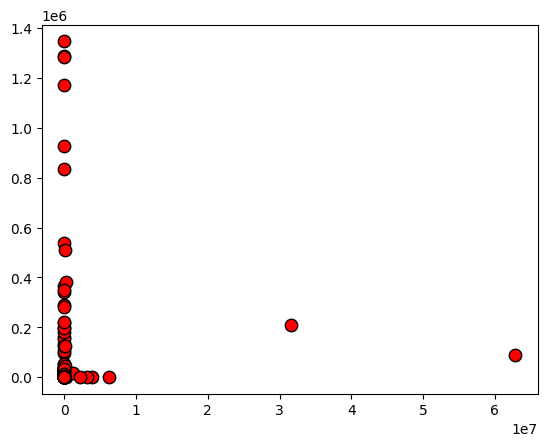

In [35]:
outliers = data[data['anamoly']]
plt.scatter(
    outliers['src_bytes'],
    outliers['dst_bytes'],
    color='red',
    label='outliers',
    edgecolors='k',
    s=80
)